### Formulation

Objective: $\min_{p^g, \theta, p^f, z} \sum_{i \in \mathcal{N}} \sum_{j \in \mathcal{G}_i} c_j p_j^g$       (13a)

-------

**Subject to constraints:**

Power Balance (Enforces Nodal power):    
$\sum_{j \in \mathcal{G}_i} p_j^g - \sum_{e \in \mathcal{E}_i} p_e^f + \sum_{e \in \mathcal{E}_i^R} p_e^f = \sum_{j \in \mathcal{L}_i} p_j^d + g_i^s \quad \forall i \in \mathcal{N}$ &emsp;&emsp;&emsp;&emsp;  \(13b), [1]

DC Power Flow (Express active power flow on each branch, if break is close (1) using binary 0,1):   
$-b_e(\theta_i - \theta_j) - p_e^f = 0$ if $z_e = 1 = \text{line closed}$, $e = (i,j) \in \mathcal{E}$. &emsp;&emsp;&emsp;&emsp;  \(13c), [1][2][3]  
- The idea of big M is that we can turn off/on constraints with binary variables. 
- Large M can relax/deactivate a constraint when binary var is 0, and enforce it when binary var is 1.
- $z_e = z_{ij} =z_{nm}$ &emsp;&emsp;[4]

Should we try and enforce it via Big-M (active power flow on each branch)?:    
$-M(1-z_e) \leq -b_e(\theta_i - \theta_j) - p_e^f \leq M(1-z_e)$ for all $e = (i,j) \in \mathcal{E}$. &emsp;&emsp;\(13d),[1][2][3]
- If we did this, we could get $-b_e(\theta_i - \theta_j) - p_e^f = 0, \text{when}, z_e = 1$

Voltage Angle Difference Limits (restrict voltage angle diff) with Big-M:   
$\underline{\Delta\theta}_e - M(1-z_e) \leq \theta_i - \theta_j \leq \overline{\Delta\theta}_e + M(1-z_e)$ for all $e = (i,j) \in \mathcal{E}$. &emsp;&emsp;&emsp;  \(13d), [1][3]

Reference Bus (fixes its voltage angle to zero):  
$\theta_{\text{ref}} = 0$ &emsp;&emsp;&emsp;\(13e), [1]

Generation Limits(active power generation limit at bus_i):   
$\underline{p}_i^g \leq p_i^g \leq \overline{p}_i^g$ for all $i \in \mathcal{G}$. &emsp;&emsp;&emsp;\(13f),[1]

Flow Limits (upper thermal limits) of Line:   
$-\overline{S}_e \cdot z_e \leq p_e^f \leq \overline{S}_e \cdot z_e$ for all $e \in \mathcal{E}$. &emsp;&emsp;&emsp;  \(13g), [1][3]
- So that when $z_e = 0$, the flow $p_e^f = 0$. &emsp;&emsp;&emsp;[3]

Binary Line Status:  
$z_e \in \{0,1\}$ for all $e \in \mathcal{E}$. &emsp;&emsp;&emsp;[3].  
Big-M method should enable the line switching logic by the following:
1. When $z_e = 1$ (line closed): the DC power flow equation $-b_e(\theta_i - \theta_j) = p_e^f$ is active, angle differences are constrained, and flow is bounded by thermal limits. &emsp;&emsp;[3]
2. When $z_e = 0$ (line open): the Big-M terms become inactive, forcing $p_e^f = 0$, and voltage angles $\theta_i, \theta_j$ are decoupled. &emsp;&emsp;[2][3]

---- Reference ----

[1] Klamkin, M., Tanneau, M., & Van Hentenryck, P. (2025). PGLearn--An Open-Source Learning Toolkit for Optimal Power Flow. arXiv preprint arXiv:2505.22825.   
[2] https://en.wikipedia.org/wiki/Big_M_method  
[3] Meng, D., Haider, R., & van Hentenryck, P. (2025). Flow-Aware GNN for Transmission Network Reconfiguration via Substation Breaker Optimization. arXiv preprint arXiv:2508.01951.  
[4] Van Hentenryck, P., & Coffrin, C. (2015). Transmission system repair and restoration. Mathematical Programming, 151(1), 347-373.   
[5] https://www.youtube.com/watch?v=grGWsUHdWQM

### Quick ref:
From PG learn, model 4:
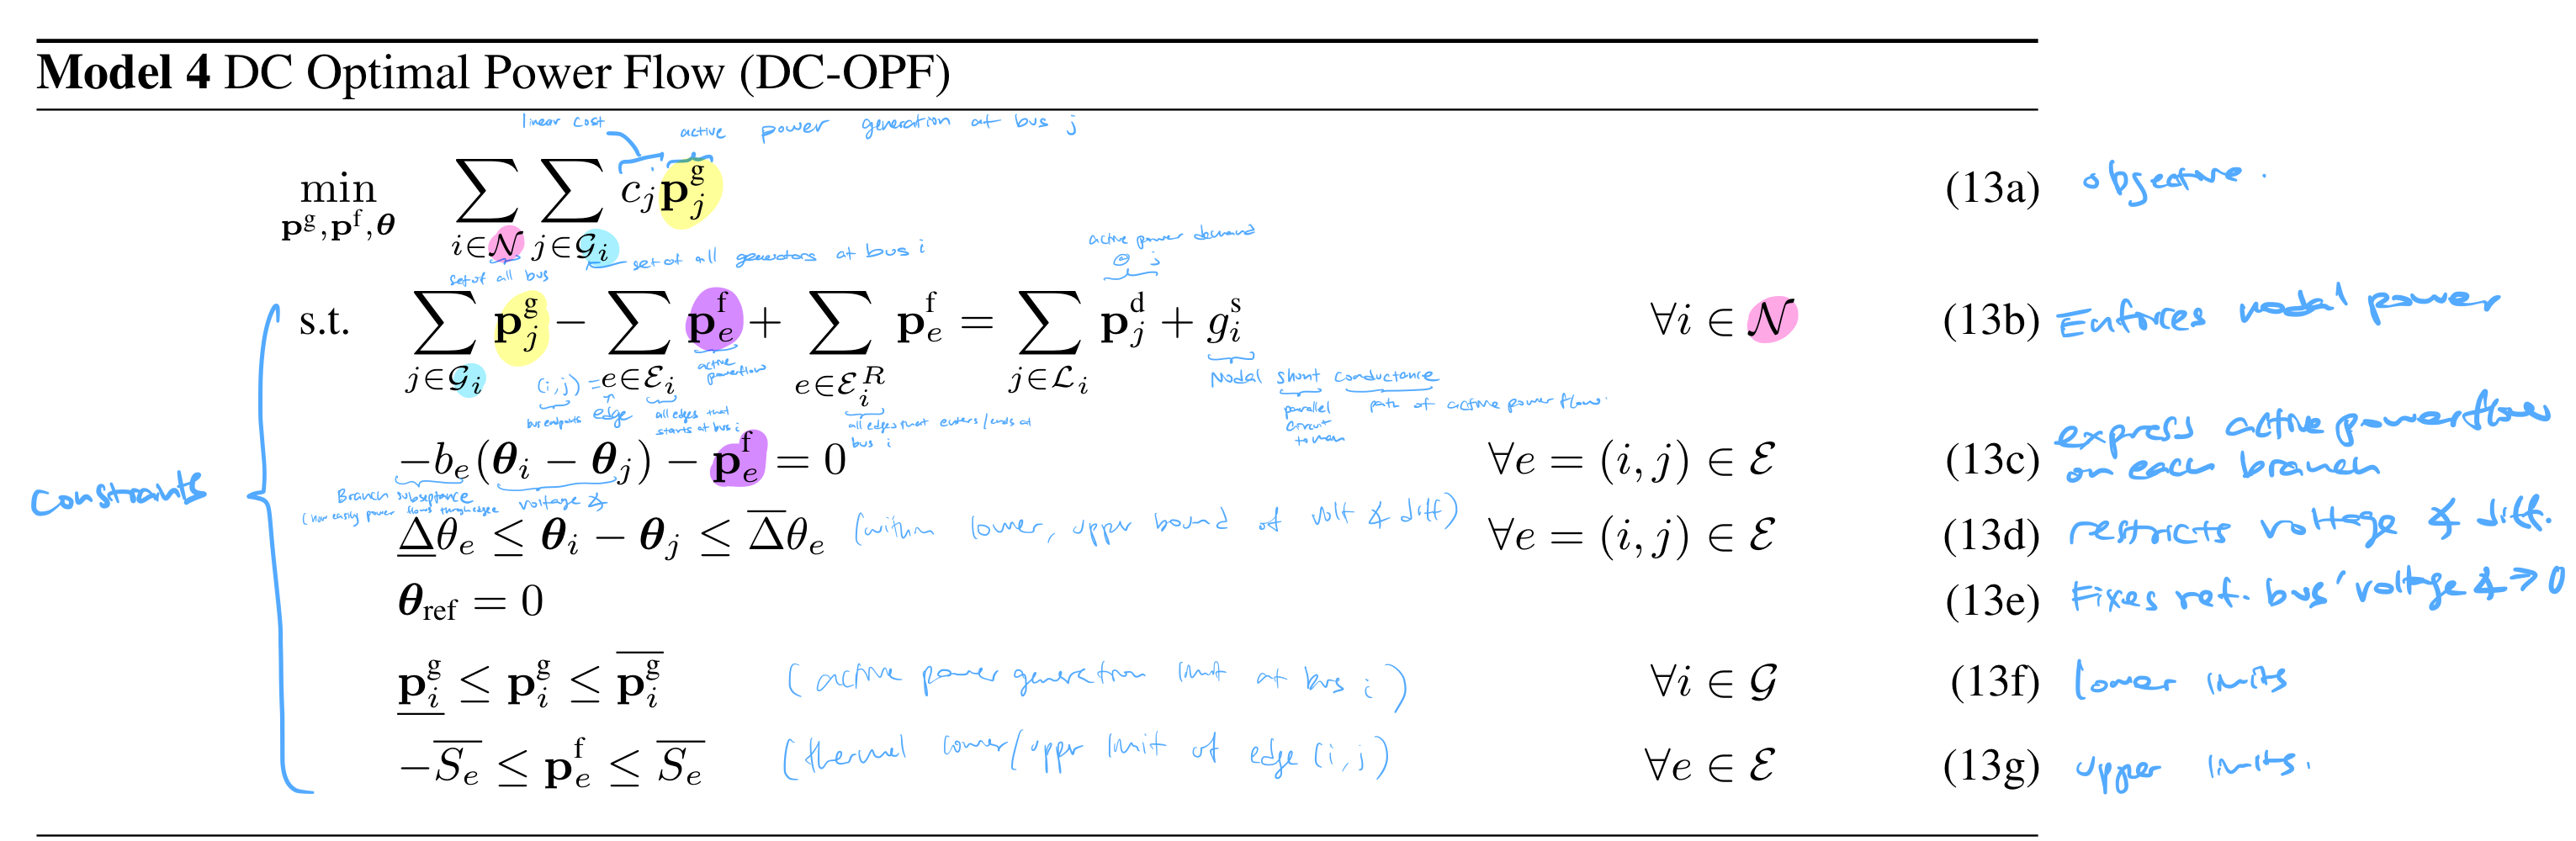

From flow aware, section 3:
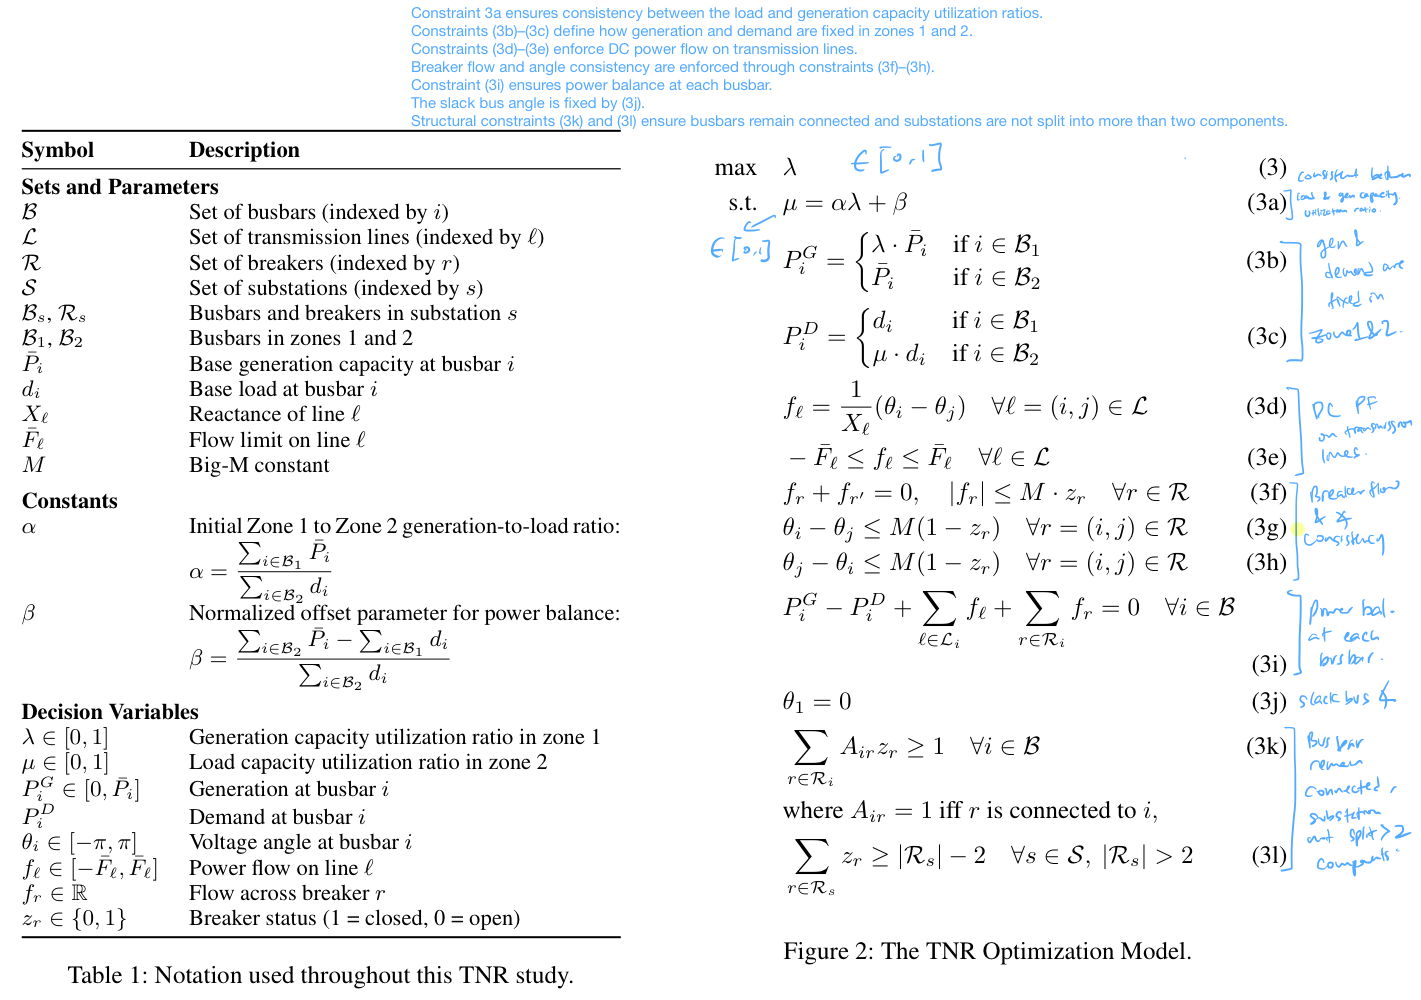